# **Breast Cancer Wisconsin - EDA & Preprocessing**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.utils import *

## **Data Loading**

In [2]:
df = load_breast_cancer_data(source="csv")
df.head()

Read CSV from: D:\IT\Machine Learning\Logistic-Regression-from-Scratch\data\processed\data.csv...
Have read 569 feartures 31 columns


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(f"Shape: {df.shape}")
df.info()

Shape: (569, 31)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se             

**Note**: The original dataset contained an Id column and an empty Unnamed: 32 column. Since we have already dropped these columns during the initial preprocessing, there are no missing values remaining.

In [4]:
missing = df.isna().sum()
print("Missing values:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

Missing values:
No missing values found.


In [5]:
df.describe().T.style.background_gradient(cmap='Greens', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dimension_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


## **Class Distribution**

In [6]:
print("Label distribution:")
counts = df[TARGET_COL].value_counts()
print(f"Benign (B)    : {counts.get('B', 0):,} samples ({counts.get('B',0)/len(df)*100:.1f}%)")
print(f"Malignant (M) : {counts.get('M', 0):,} samples ({counts.get('M',0)/len(df)*100:.1f}%)")

Label distribution:
Benign (B)    : 357 samples (62.7%)
Malignant (M) : 212 samples (37.3%)


In [7]:
fig = plot_class_distribution(df)
fig.show()

As illustrated in the charts, the dataset contains 357 Benign samples (62.7%) and 212 Malignant samples (37.3%). Given that the class distribution is relatively balanced, the application of **SMOTE** is optional. This ~60:40 ratio indicates only a mild imbalance, meaning the model is unlikely to develop a severe bias towards the majority class. Therefore, we can prioritize standard preprocessing steps-such as feature scaling and normalization-and evaluate the baseline model using robust metrics like the F1-score or AUC-ROC before introducing any resampling techniques.

## **Feature Value Ranges**

An examination of the feature value ranges visually confirms that the 30 variables operate on drastically different numerical scales. For instance, features like **`area_worst`** and **`area_mean`** exhibit extreme maximum values exceeding 4,000 and 2,500 respectively, while **`fractal_dimension_mean`** remains comparatively minute, clustering tightly near zero. This immense magnitude disparity makes feature standardization (such as applying StandardScaler) a mandatory preprocessing step. Without this normalization, features with inherently larger values would disproportionately dominate the objective functions of distance-based or gradient-based models, skewing the learning process. Therefore, standardizing ensures all features contribute uniformly to the model's final performance.

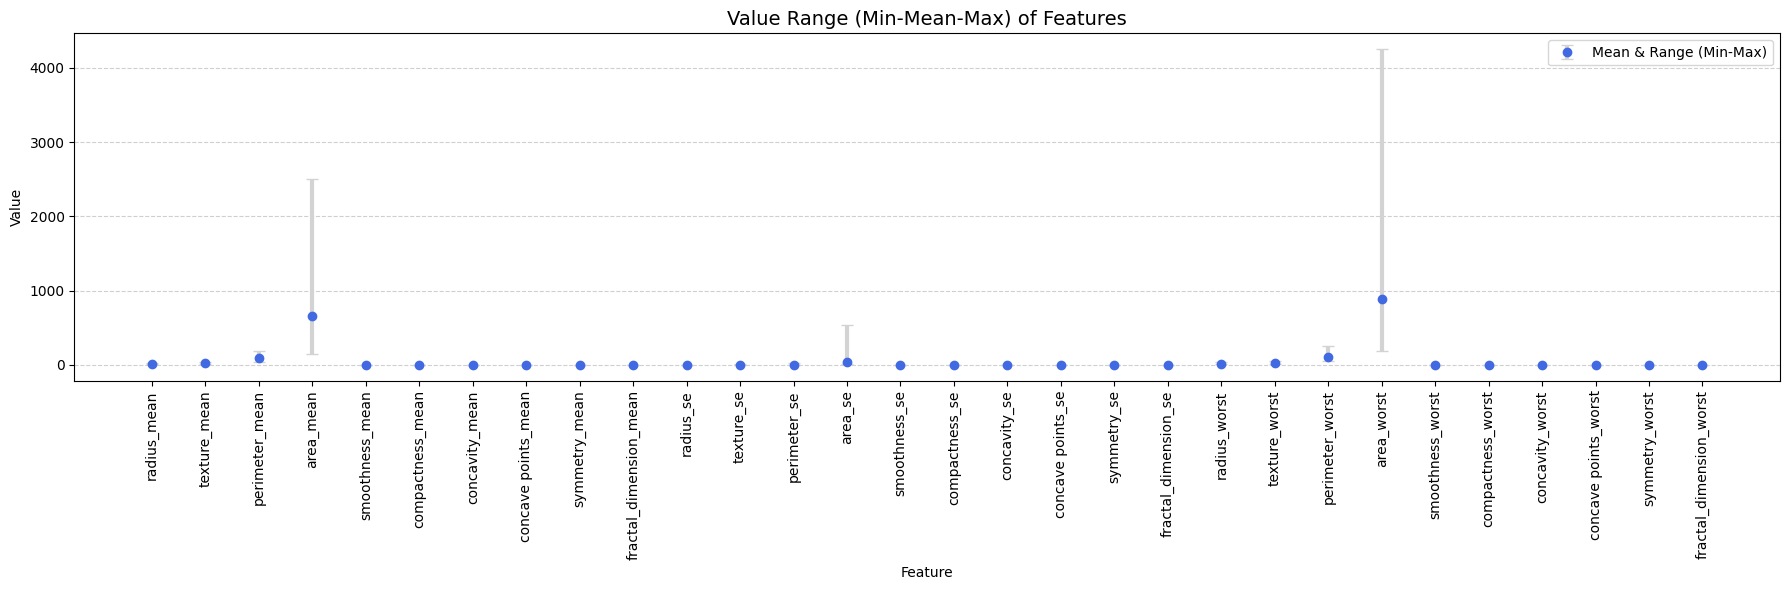

In [8]:
fig = plot_feature_range(df)
plt.show()

## **Feature Distributions by Group**

Boxplots serve as an effective visual tool to evaluate how well each individual feature separates the Malignant (M) and Benign (B) classes:

Non-overlapping (or minimally overlapping) boxes: Indicate strong discriminative power. For instance, features like **`perimeter_mean`**, **`area_mean`**, and **`concave points_worst`** show clear visual separation between the two classes, suggesting they will be highly valuable for the model's decision boundaries.

Heavily overlapping boxes: Denote weak discriminative power. Features such as **`fractal_dimension_mean`** and **`smoothness_mean`** exhibit significant overlap, meaning the model will find it difficult to classify instances based solely on these variables.

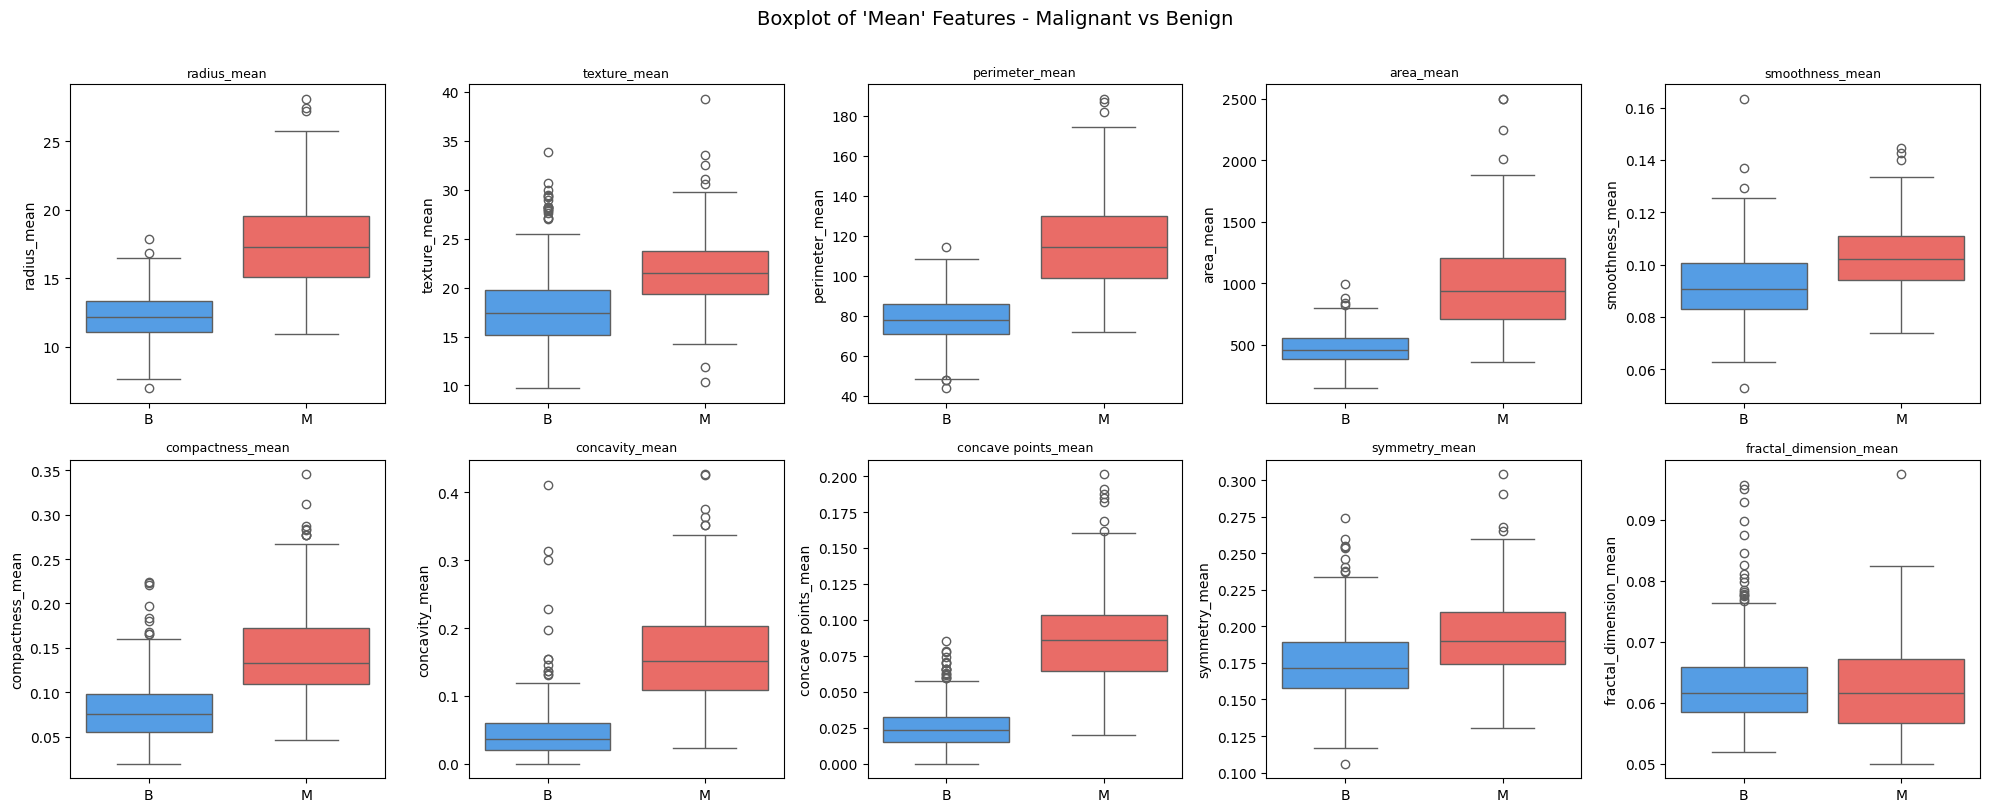

In [9]:
fig = plot_feature_boxplots(df, group="mean")
plt.show()

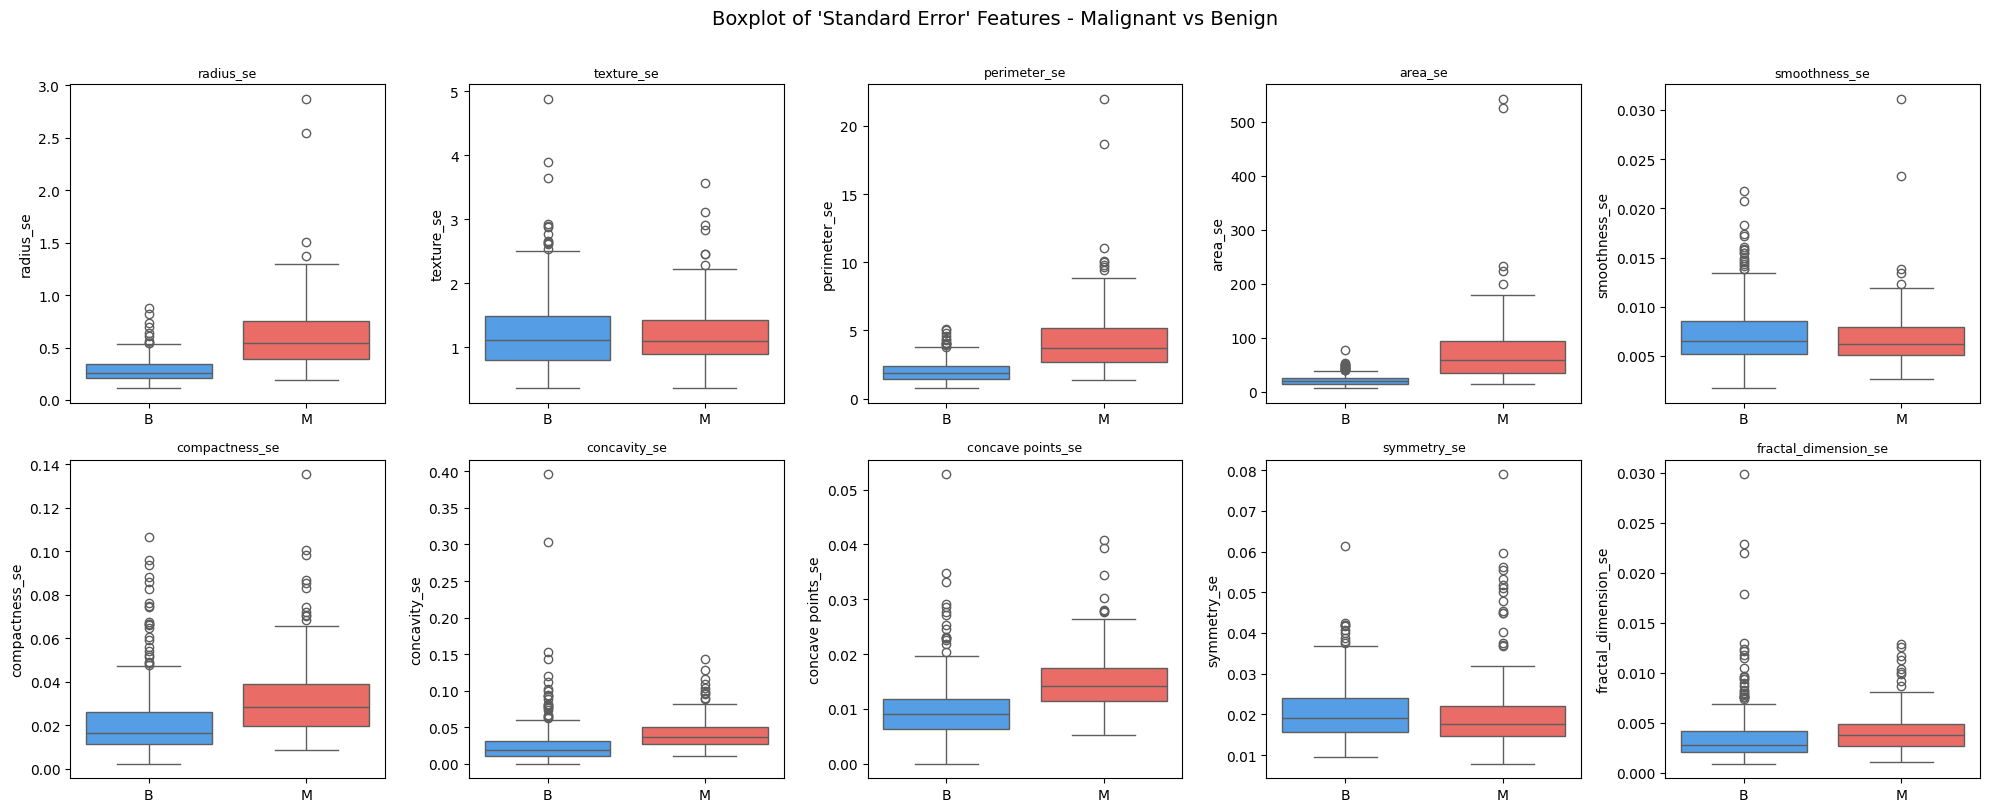

In [10]:
fig = plot_feature_boxplots(df, group="se")
plt.show()

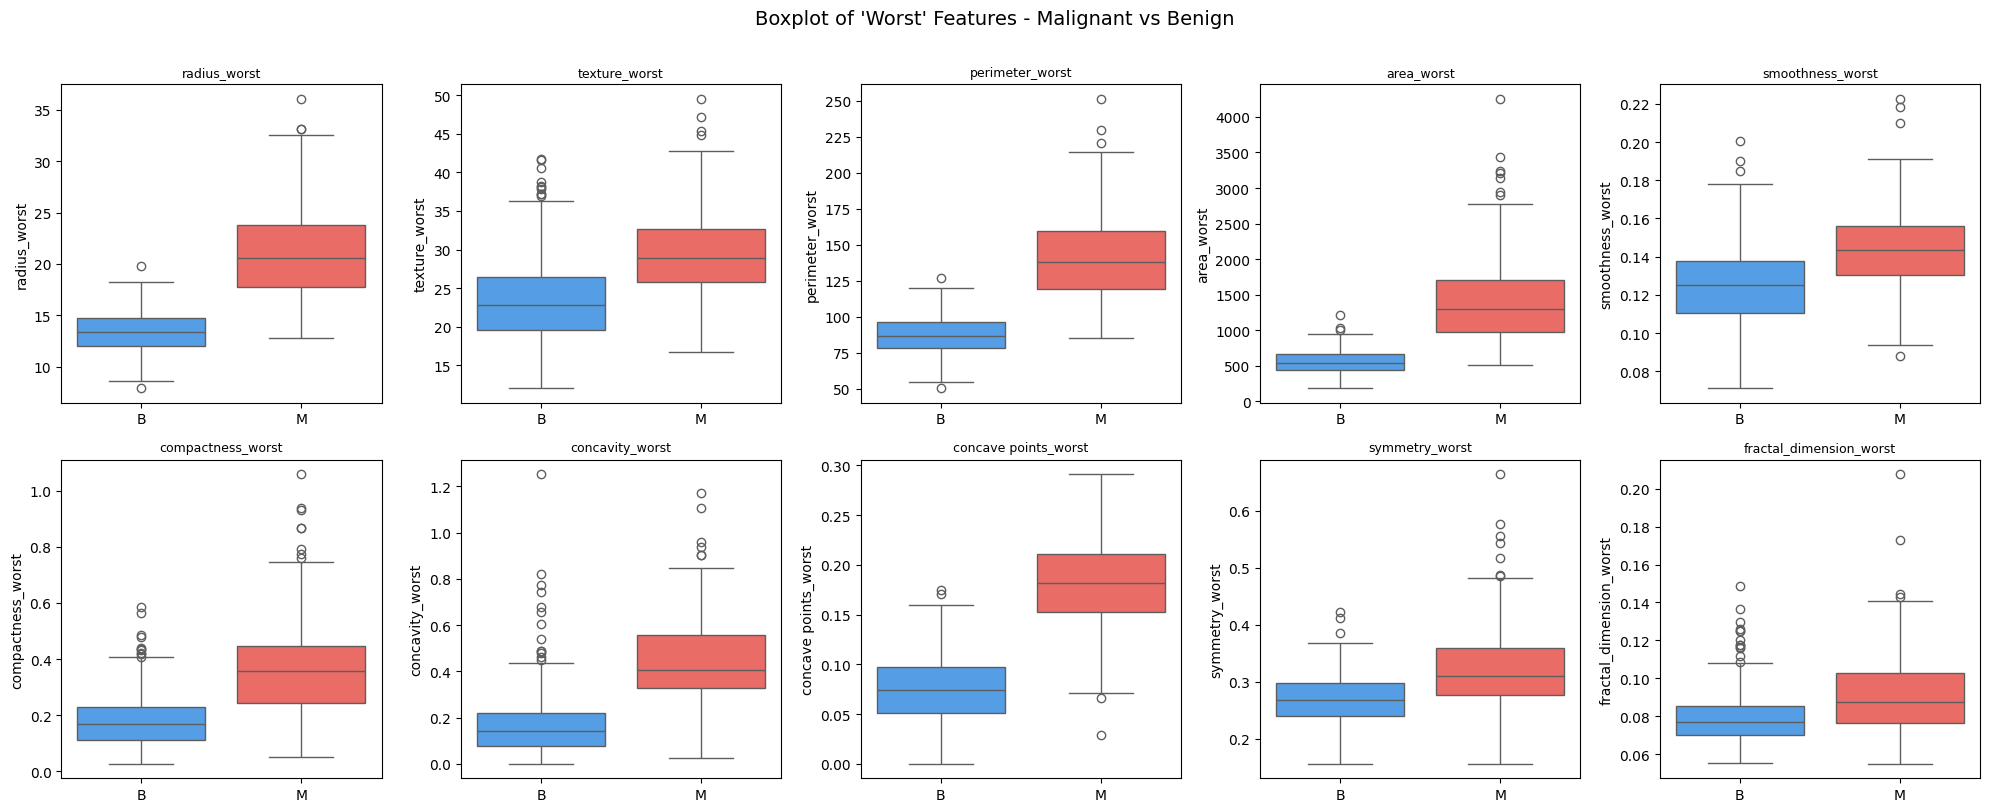

In [11]:
fig = plot_feature_boxplots(df, group="worst")
plt.show()

A comparative analysis of the boxplots reveals that the **`_worst`** feature group generally exhibits clearer class separation than the **`_mean`** and **`_se`** groups. Standout features with strong discriminative power include **`radius_worst`**, **`perimeter_worst`**, **`area_worst`**, and **`concave points_worst`**. From a clinical perspective, these visualizations strongly suggest that malignant tumors are characterized by significantly larger dimensions and more pronounced concavity compared to benign tumors.

## **Top Discriminative Features - Violin Plots (Cohen's *d*)**

Cohen's *d* measures the **effect size**, how well a feature separates the two classes in terms of standardized mean difference:

$$d = \frac{|\mu_M - \mu_B|}{\sigma_{pooled}}$$

Where $\sigma_{pooled}$ (the pooled standard deviation) is estimated by the square root of the average of the two group variances:$$\sigma_{pooled} = \sqrt{\frac{\sigma_M^2 + \sigma_B^2}{2}}$$
with $\sigma_M^2$ and $\sigma_B^2$ denoting the variance of the feature within the Malignant and Benign groups respectively.

**Note on Cohen's d Interpretation:**

Cohen's d measures the effect size, indicating how well a feature separates the two classes:
- $d < 0.2 \rightarrow$ Small effect
- $0.2 \le d < 0.8 \rightarrow$ Medium effect
- $d \ge 0.8 \rightarrow$ Large effect (high discriminative power)

Features with $d > 1.5$ are considered to have an exceptionally strong predictive signal.

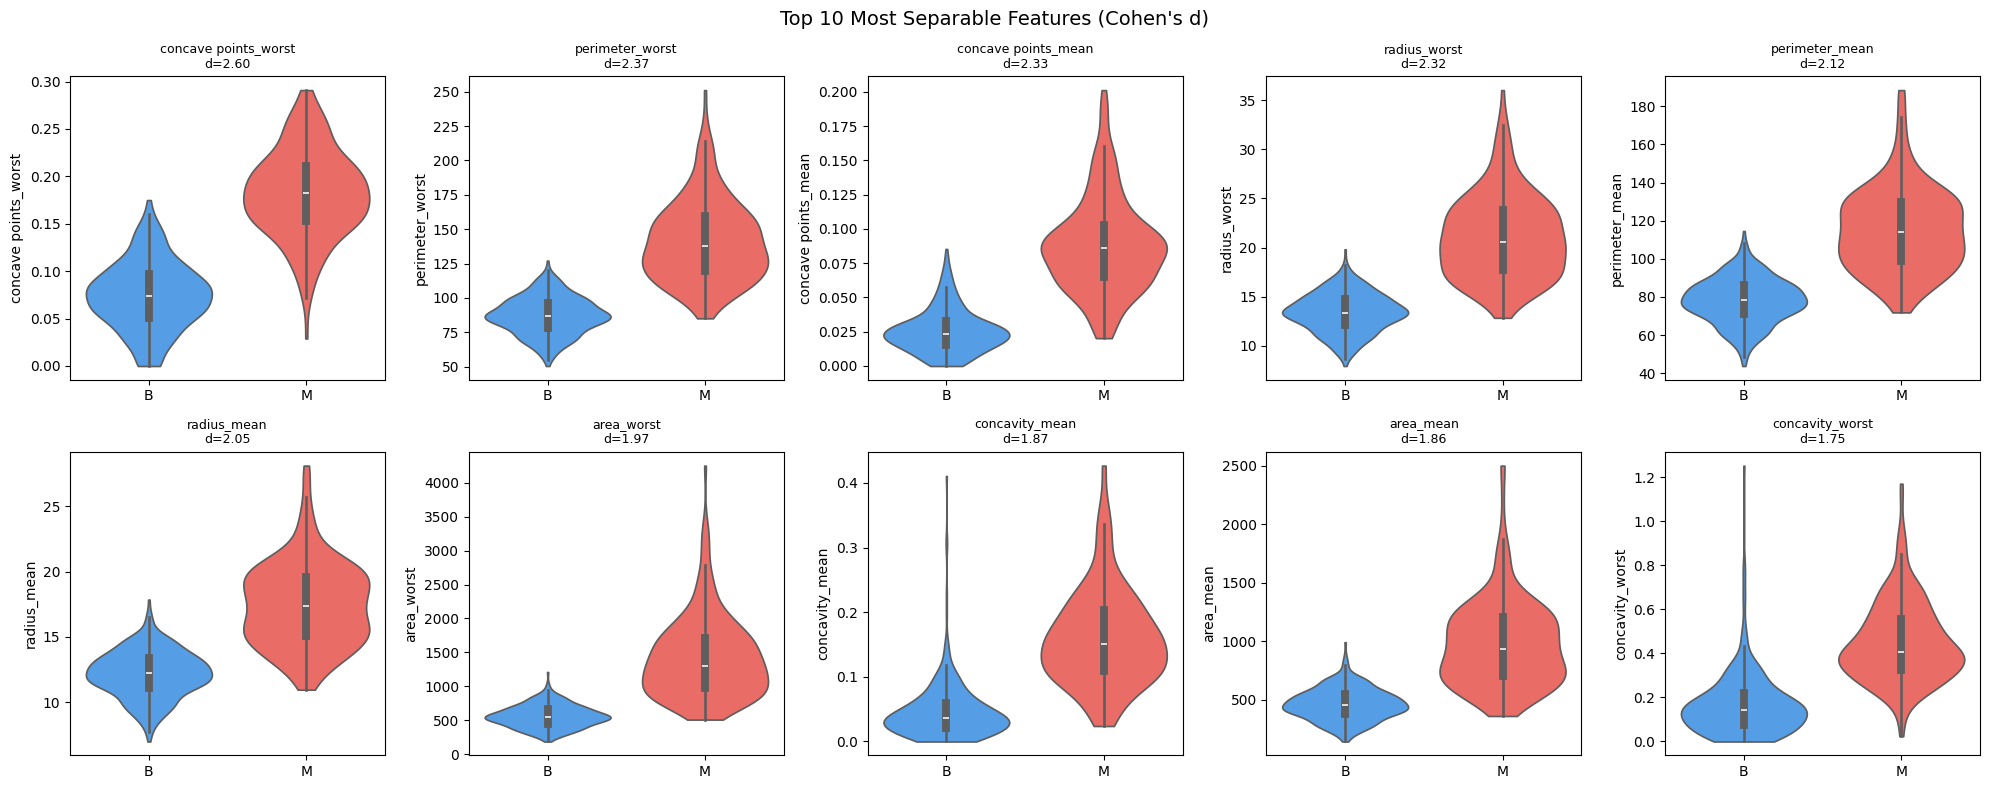

In [12]:
fig = plot_violin(df)
plt.show()

The violin plots illustrate the top 10 features ranked by their effect size, quantified using Cohen's d. Based on standard interpretation thresholds (where $d \ge 0.8$ represents a large effect size), we can confidently conclude:
- Every single feature in the top 10 exhibits a Cohen's d vastly exceeding 1.5. This indicates a massive separation between the mean values of the Benign (B) and Malignant (M) classes, confirming them as exceptionally strong predictive signals for our model.
- The highest-ranking feature, **`concave points_worst`**, achieves an outstanding $d = 2.60$. The accompanying violin plot visually corroborates this, showing minimal overlap in the data distribution between the two classes.
- Aligning with our earlier boxplot analysis, the **`_worst`** features strongly dominate this top 10 list (e.g., **`perimeter_worst`** at $d=2.37$, **`radius_worst`** at $d=2.32$), mathematically validating their critical role in distinguishing malignant tumors.

## **Feature Density Plots - KDE by Class**

Kernel Density Estimation (KDE) plots show the **probability density** of each feature for each class:
- **Well-separated peaks** $\to$ high discriminative power
- **Near-identical curves** $\to$ low discriminative power

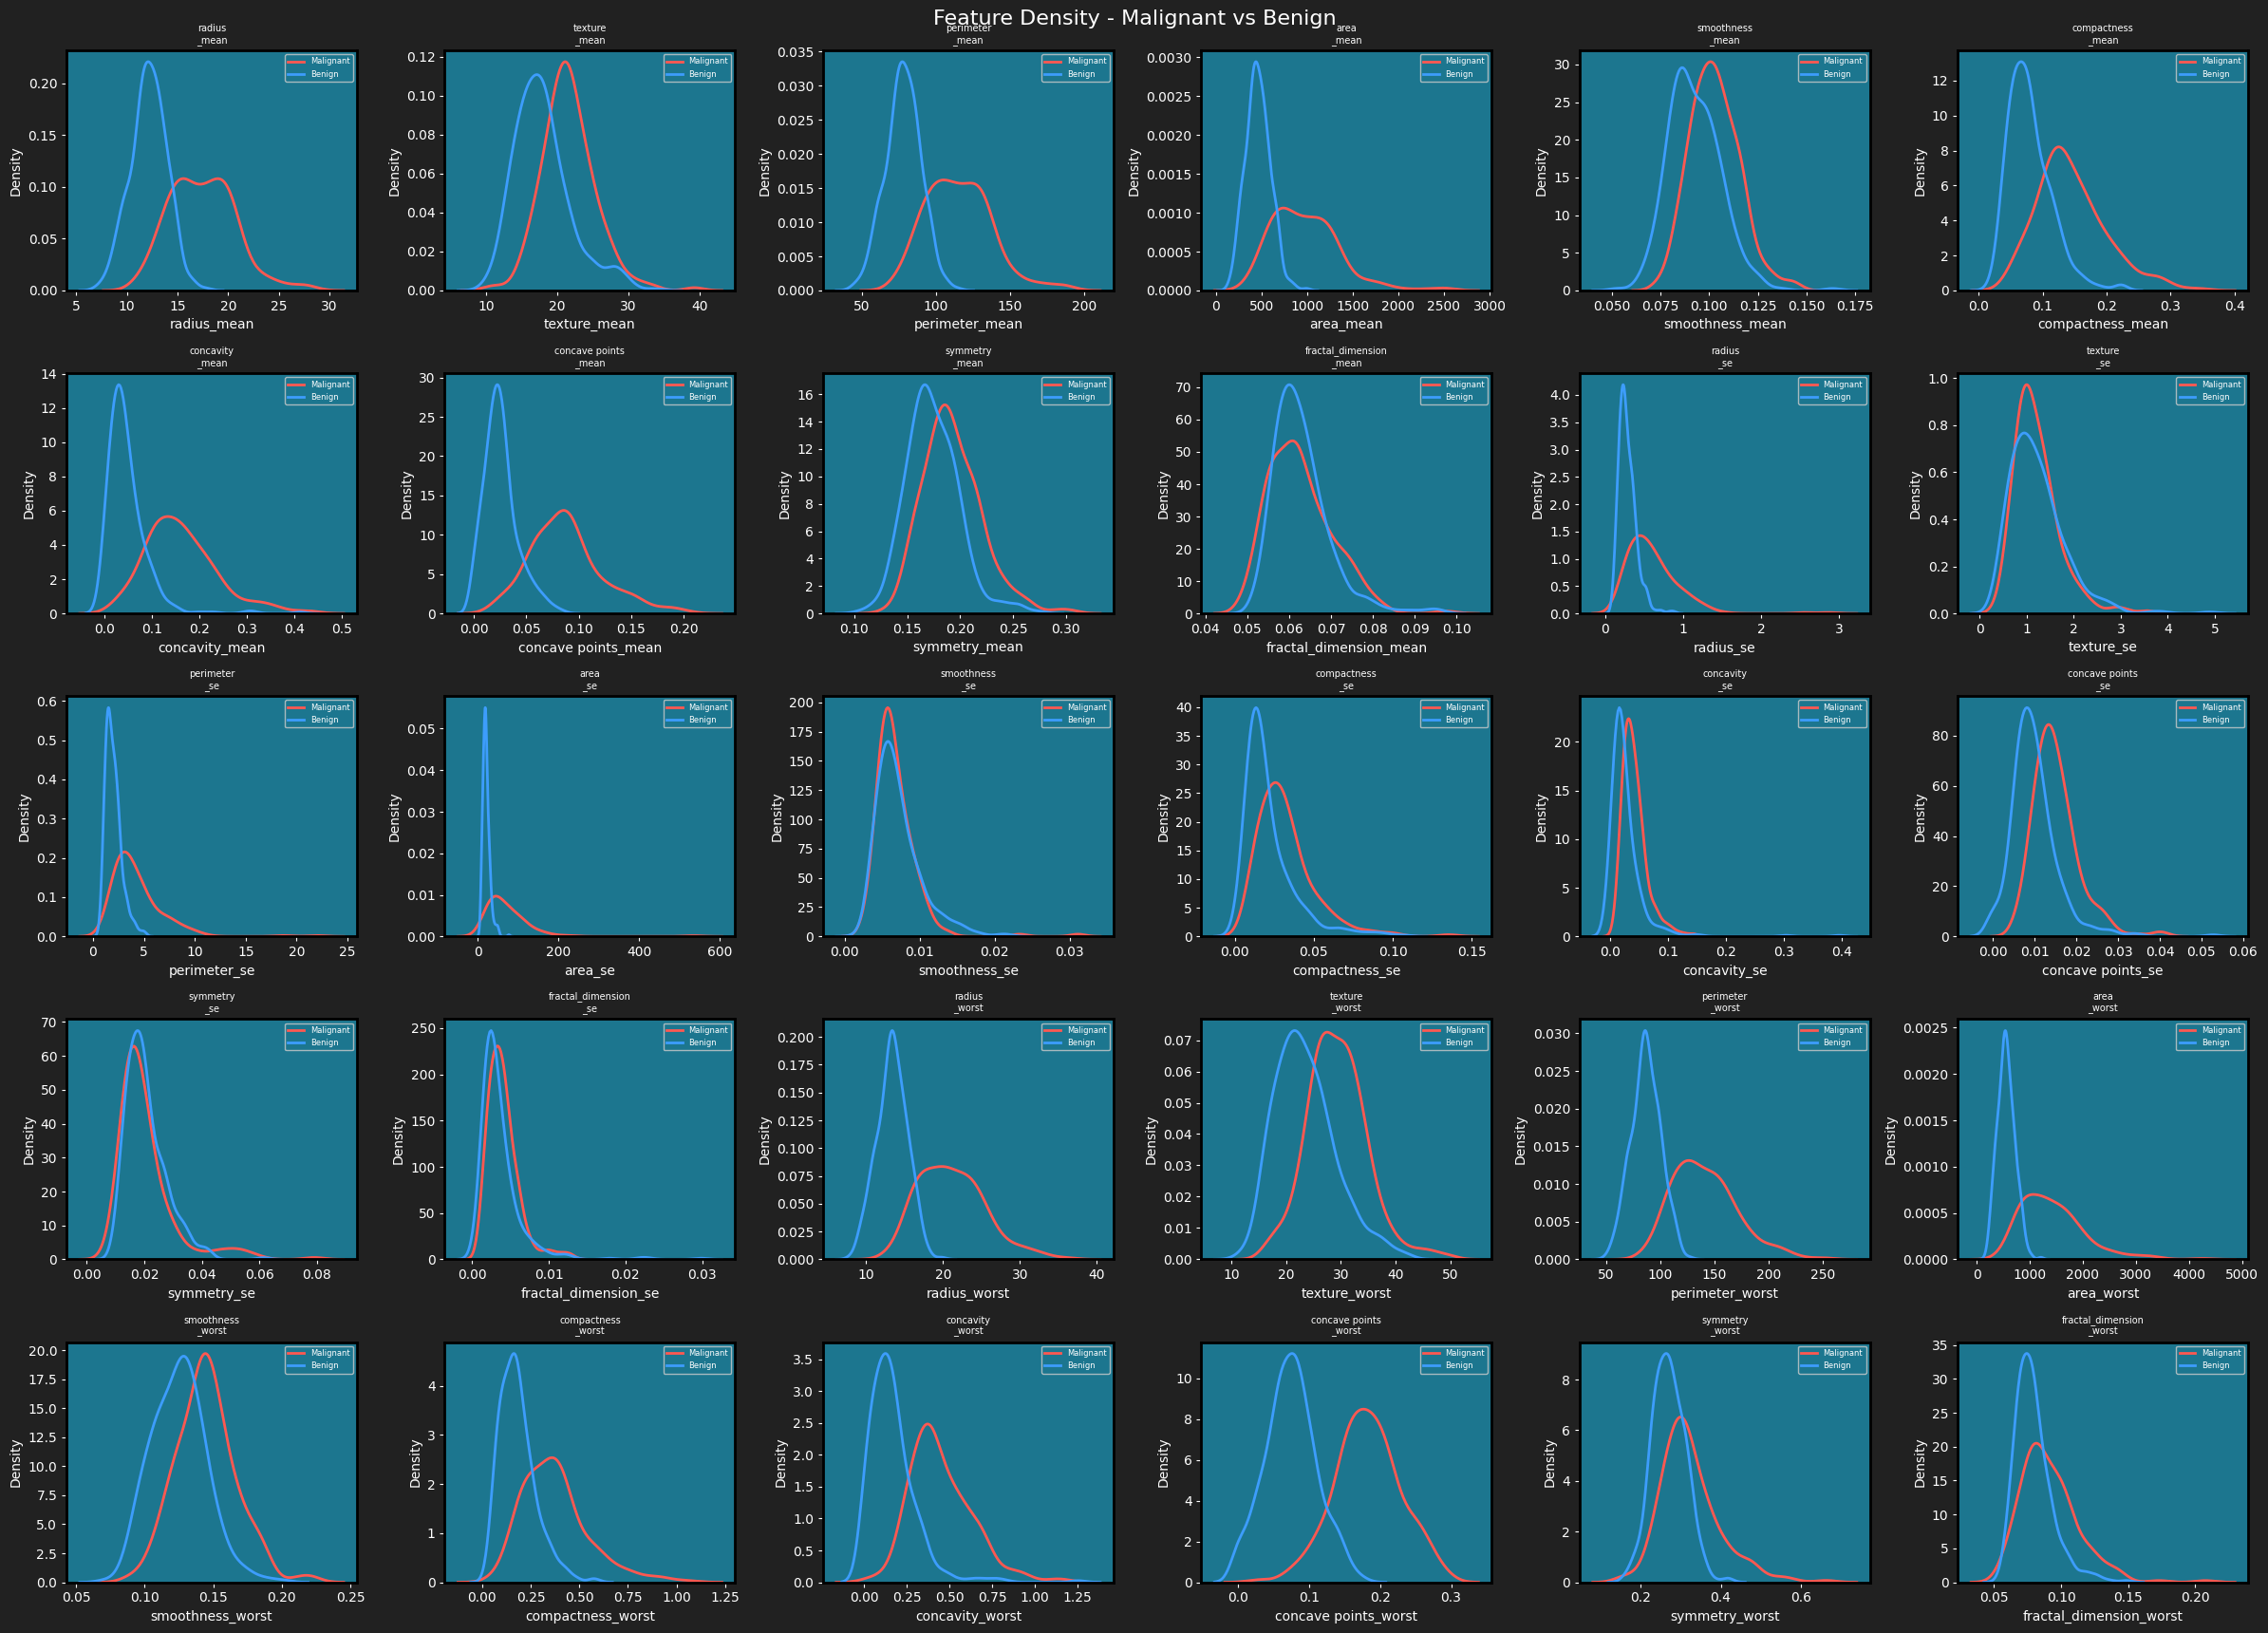

In [13]:
fig = plot_feature_density(df)
plt.show()

Applying the aforementioned criteria to the KDE plots reinforces our earlier findings. Features such as **`concave points_worst`** and **`perimeter_worst`** exhibit well-separated peaks, confirming their high discriminative power. In contrast, standard error (**`_se`**) metrics and specific mean features like **`fractal_dimension_mean`** display near-identical curves, indicating weak class separation. Furthermore, the density plots reveal a recurring structural pattern: Benign class distributions (blue) tend to be narrow and highly concentrated, whereas Malignant distributions (red) are characteristically wider and right-skewed, reflecting the higher variance and structural irregularity typical of malignant cells.

## **Correlation Analysis**

Heatmaps are plotted separately for each feature group (**`_mean`**, **`_se`**, **`_worst`**) to improve readability, given the 30×30 full matrix would be difficult to interpret.

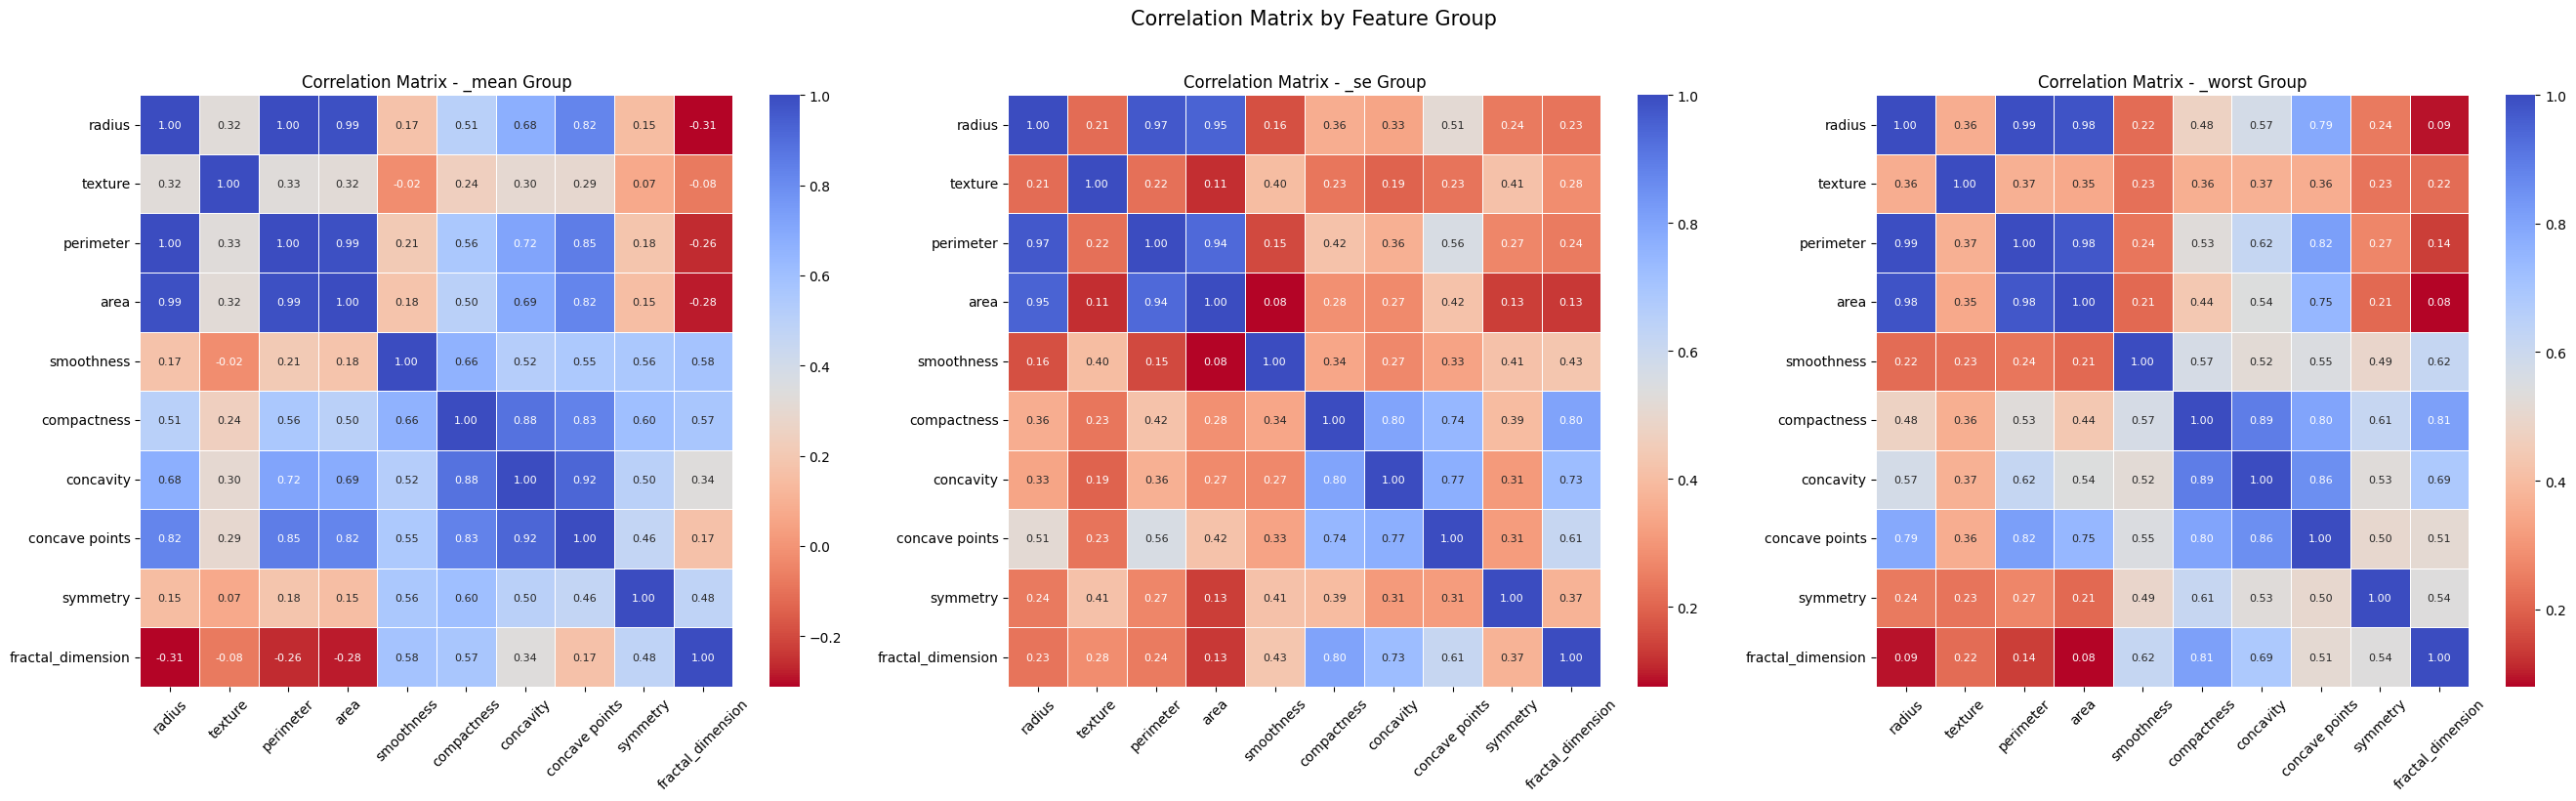

In [14]:
fig = plot_correlation_heatmaps(df)
plt.show()

An analysis of the intra-group correlation matrices reveals significant feature redundancy. Most notably, dimensional features (**`radius`**, **`perimeter`**, and **`area`**) demonstrate near-perfect positive correlations (r > 0.9), which is expected given their shared geometrical nature. Another strong correlation cluster exists among shape-descriptor features like **`compactness`**, **`concavity`**, and **`concave points`**. These structural patterns provide strong evidence of multicollinearity within the dataset. Consequently, employing a dimensionality reduction technique such as Principal Component Analysis (PCA) will be a critical next step to mitigate this issue and condense the feature space.

Moving forward, we evaluate how these features correlate directly with the binary target variable (Benign=0, Malignant=1):

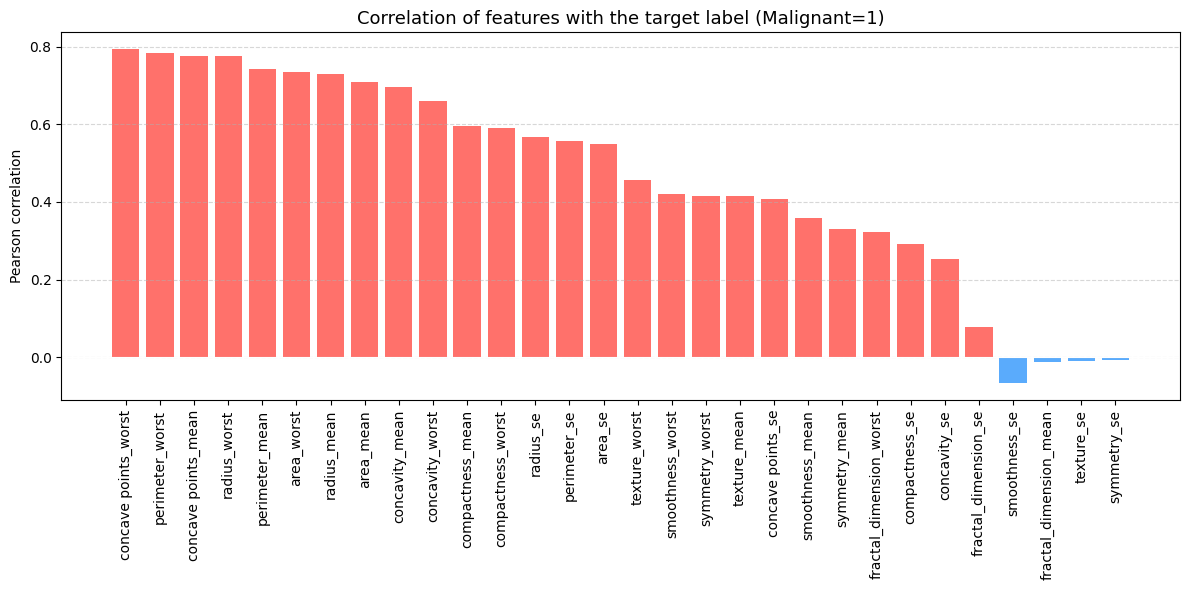

Top 10 features most strongly correlated with Malignant:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610


In [15]:
df_corr = df.copy()
df_corr['diagnosis_num'] = (df_corr['diagnosis'] == 'M').astype(int)

target_corr = (
    df_corr.select_dtypes(include=np.number)
    .corr()['diagnosis_num']
    .drop('diagnosis_num')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = [COLORS['malignant'] if v > 0 else COLORS['benign'] for v in target_corr]
ax.bar(target_corr.index, target_corr.values, color=colors_bar, alpha=0.85)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title("Correlation of features with the target label (Malignant=1)", fontsize=13)
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 10 features most strongly correlated with Malignant:")
print(target_corr.head(10).to_string())

## **Outlier Analysis**

In Breast Cancer classification outliers primarily reflect **natural biological variability** in cell morphology. Malignant tumors tend to produce more outliers due to their irregular and heterogeneous cell structure.

In [16]:
fig = plot_outlier_distribution(df, z=3.0)
fig.show()

An analysis of the outlier proportions ($|z| > 3.0$) reveals a critical insight: for the vast majority of features, nearly 100% of the identified outliers belong to the Malignant class. This indicates that these extreme values are not random noise or anomalies; rather, they represent a fundamentally distinct data distribution. Calculating a global z-score across the mixed dataset inherently centers the mean and standard deviation around the majority Benign class. Consequently, the Malignant instances-which naturally possess higher means and different standard deviations-are mechanically flagged as outliers. Therefore, these points must be strictly preserved, as they carry the primary predictive signal for cancer detection.

## **Principal Component Analysis (PCA)**

In [17]:
# Scaling features
feature_cols = df.select_dtypes(include=np.number).columns
X = df[feature_cols].values
y_labels = df[TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape after scaling: {X_scaled.shape}")

Shape after scaling: (569, 30)


**Explained Variance Ratio**

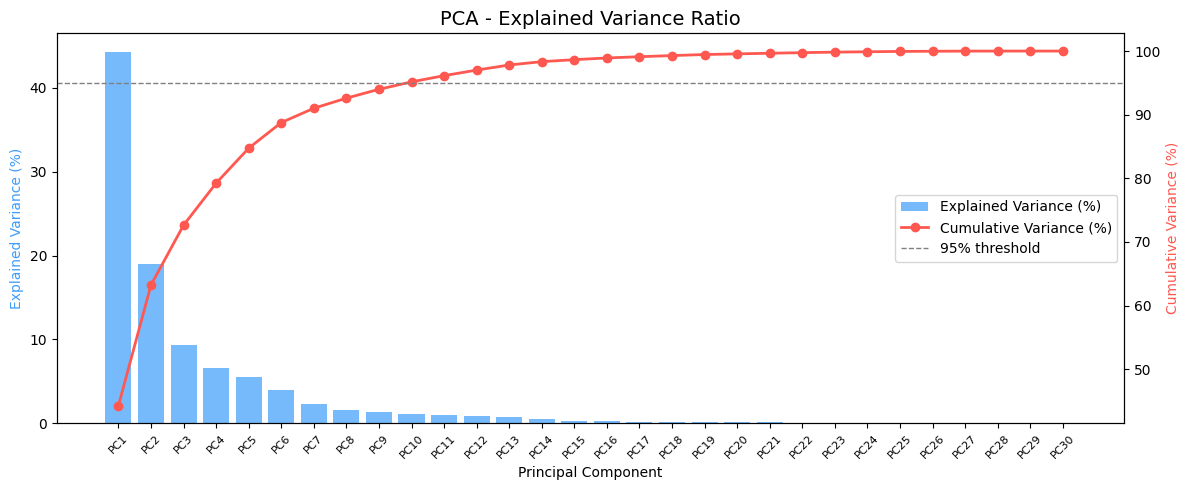

In [18]:
pca_full = PCA(n_components=X_scaled.shape[1], random_state=42)
pca_full.fit(X_scaled)

fig = plot_pca_explained_variance(pca_full.explained_variance_ratio_)
plt.show()

The Principal Component Analysis (PCA) plot illustrates both the individual and cumulative explained variance across all components. Key observations include:

- ***High Information Concentration***: The first principal component (PC1) alone captures a substantial portion of the total variance (over 40%), while PC2 accounts for nearly 20%. The fact that the first few components capture so much variance confirms our earlier correlation analysis: the original 30 features contained highly redundant information (multicollinearity).

- ***Reaching the 95% Threshold***: The cumulative variance curve (red line) crosses the 95% threshold dashed line at the 10th principal component (PC10).

- ***Dimensionality Reduction Strategy***: This visual evidence suggests that we can drastically reduce our feature space from the original 30 dimensions down to just 10 principal components while still retaining 95% of the dataset's critical predictive information. This 10-component subset will effectively eliminate multicollinearity and reduce computational complexity without compromising the model's performance.

**PCA 2D Scatter**

In [19]:
pca_3 = PCA(n_components=3, random_state=42)
X_pca = pca_3.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df[TARGET_COL] = y_labels

print(f"PC1 explains: {pca_3.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca_3.explained_variance_ratio_[1]*100:.1f}%")
print(f"PC3 explains: {pca_3.explained_variance_ratio_[2]*100:.1f}%")

PC1 explains: 44.3%
PC2 explains: 19.0%
PC3 explains: 9.4%


In [20]:
# PCA 2D
fig = plot_pca_scatter(pca_df, mode='2d')
fig.show()

In [21]:
# PCA 3D
fig = plot_pca_scatter(pca_df, mode='3d')
fig.show("browser")

The projection onto the first two and three principal components reveals two key observations:

- ***Clear separation***: Malignant and Benign instances form largely distinct clusters, confirming that the leading principal components capture variance that correlates directly with pathological differences between the two classes.
- ***Residual overlap***: The clusters are not perfectly linearly separable, a region of overlap remains, indicating that a linear boundary alone will not achieve perfect classification.

Together, these observations justify the use of Logistic Regression: the overall spatial separation suggests a linear decision boundary will be effective, while the probabilistic output of the model naturally handles uncertainty in the overlapping region.

**PCA Loadings**

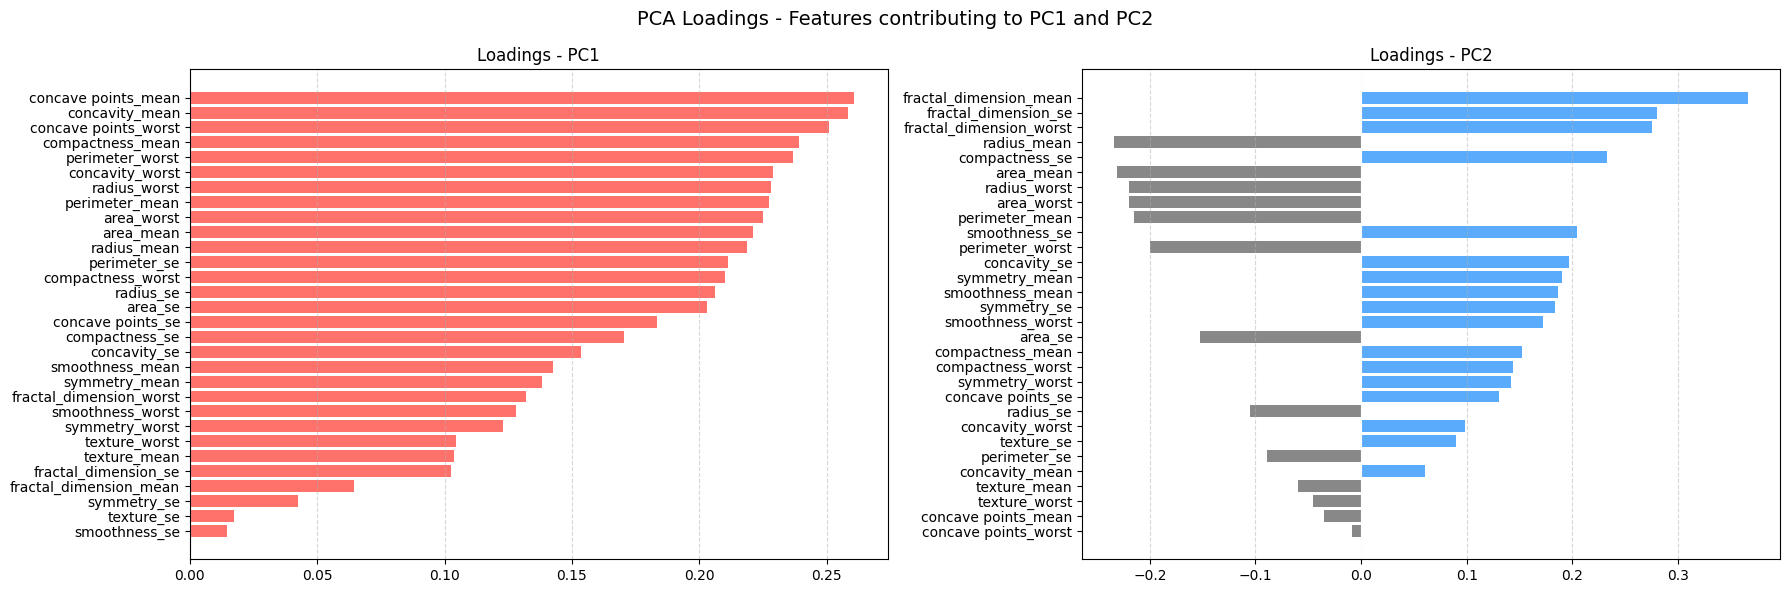

In [22]:
loadings = pd.DataFrame(
    pca_3.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=feature_cols,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for ax, col, color in [(ax1, 'PC1', COLORS['malignant']), (ax2, 'PC2', COLORS['benign'])]:
    data = loadings[col].sort_values(key=abs, ascending=True)
    bar_colors = [color if v > 0 else COLORS['gray'] for v in data.values]
    ax.barh(data.index, data.values, color=bar_colors, alpha=0.85)
    ax.axvline(0, color='white', linewidth=0.8)
    ax.set_title(f"Loadings - {col}", fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle("PCA Loadings - Features contributing to PC1 and PC2", fontsize=14)
plt.tight_layout()
plt.show()

Analyzing the loadings reveals that PC1 is predominantly driven by size and shape metrics (such as concave points_worst and perimeter_worst), perfectly mirroring our previous Cohen's d findings. Since the core predictive variance captured by PCA is already highly represented by these specific raw features, our decision to skip PCA in the modeling pipeline is fully justified. This approach ensures high performance while preserving crucial clinical interpretability.

## Preprocessing Pipeline
Based on the EDA findings, we construct a straightforward preprocessing pipeline.

In [23]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_names = preprocess_breast_cancer_data(df)

print(f"\nNumber of features: {X_train.shape[1]}")
print(f"Feature names: {feature_names[0:-1]}")

After scaling:
X_train : (398, 30)  | Malignant: 149 / 398
X_val   : (57, 30)   | Malignant: 21 / 57
X_test  : (114, 30)  | Malignant: 42 / 114

Number of features: 30
Feature names: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst']


In [24]:
print("\n==========Class Distribution in Train Set==========")
train_series = pd.Series(y_train)
print(f"    Benign (0)    : {(train_series==0).sum()} ({(train_series==0).mean()*100:.1f}%)")
print(f"    Malignant (1) : {(train_series==1).sum()} ({(train_series==1).mean()*100:.1f}%)")

print("\n=====Class Distribution in Test Set (Original)=====")
test_series = pd.Series(y_test)
print(f"    Benign (0)    : {(test_series==0).sum()} ({(test_series==0).mean()*100:.1f}%)")
print(f"    Malignant (1) : {(test_series==1).sum()} ({(test_series==1).mean()*100:.1f}%)")


==========Class Distribution in Train Set==========
    Benign (0)    : 249 (62.6%)
    Malignant (1) : 149 (37.4%)

=====Class Distribution in Test Set (Original)=====
    Benign (0)    : 72 (63.2%)
    Malignant (1) : 42 (36.8%)
